# 00 · Import & Arrange MIMIC-IV → `unified_table.csv`

This notebook builds a single **admission-level** table from the
**MIMIC-IV Clinical Database Demo v2.2** (`hosp` + `icu` modules).

**Grain:** exactly one row per hospital admission (`subject_id`, `hadm_id`).

**Purpose:** the table feeds an LLM that writes *synthetic* clinical notes, which
are then used to train a downstream BERT infection classifier. To avoid
**label leakage / shortcut learning**, several fields are masked, generalized, or
rewritten *inside this notebook* before they are saved:

| Field | Anti-leakage treatment |
|-------|------------------------|
| `primary_admission_diagnosis` | infection-revealing titles → `"Acute medical illness"` |
| `procedures` | passed through `apply_procedure_rewrites()` (dictionary hook) |
| `antibiotics_given` | drug names dropped → generic *"Empiric intravenous antibiotic therapy administered"* |

The **ground-truth label** columns (`infection_label`, `infection_categories`,
`infection_diagnoses`, `num_infection_dx`) are computed from the *full* diagnosis
list and kept in the CSV **for evaluation only** — they are dropped from the LLM
prompt downstream.

## 1 · Imports & configuration

In [5]:
import gzip
import io
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

In [6]:
# --- Locate the project root (works whether the notebook runs from the repo
# --- root or from the notebooks/ sub-folder) -------------------------------
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "00_mimic_data"
ZIP_PATH = DATA_DIR / "mimic-iv-clinical-database-demo-2.2.zip"
ZIP_ROOT = "mimic-iv-clinical-database-demo-2.2"          # top folder inside the zip
OUTPUT_PATH = DATA_DIR / "unified_table.csv"

assert ZIP_PATH.exists(), f"MIMIC demo zip not found at: {ZIP_PATH}"
print("Reading from :", ZIP_PATH)
print("Will write to:", OUTPUT_PATH)

Reading from : c:\Users\talme\Documents\LLM PROJECT - Improved\data\00_mimic_data\mimic-iv-clinical-database-demo-2.2.zip
Will write to: c:\Users\talme\Documents\LLM PROJECT - Improved\data\00_mimic_data\unified_table.csv


In [7]:
def read_mimic(rel_path, **read_csv_kwargs):
    """Read a gzip-compressed MIMIC CSV straight out of the demo zip archive.

    Parameters
    ----------
    rel_path : str
        Path *inside* the archive relative to the module root,
        e.g. ``"hosp/admissions.csv.gz"`` or ``"icu/chartevents.csv.gz"``.
    **read_csv_kwargs :
        Forwarded to :func:`pandas.read_csv` (e.g. ``usecols=[...]``).
    """
    member = f"{ZIP_ROOT}/{rel_path}"
    with zipfile.ZipFile(ZIP_PATH) as archive:
        with archive.open(member) as raw:
            data = gzip.GzipFile(fileobj=raw).read()
    return pd.read_csv(io.BytesIO(data), **read_csv_kwargs)

## 2 · Concept dictionaries & item IDs

All the domain knowledge (item IDs, keyword lists, leakage rules) lives here so the
processing functions stay clean and the anti-leakage rules are easy to audit.

In [8]:
# --- ICU chartevents item IDs (vitals) -------------------------------------
CHART_ITEMIDS = {
    "Temp_F":    223761,   # Temperature Fahrenheit  -> converted to Celsius
    "Temp_C":    223762,   # Temperature Celsius
    "HeartRate": 220045,   # Heart Rate (bpm)
    "RespRate":  220210,   # Respiratory Rate (insp/min)
}

# --- hosp labevents item IDs (infection markers) ---------------------------
LAB_ITEMIDS = {
    "WBC_max":             51301,   # White blood cell count
    "CRP_max":             50889,   # C-reactive protein
    "Bands_max":           51144,   # Band neutrophils (%)
    "Neutrophils_pct_max": 51256,   # Neutrophils (%)
}

In [9]:
# --- Infection taxonomy -----------------------------------------------------
# Ordered list: the FIRST matching category wins, so specific syndromes are
# assigned before the generic "Other infection" catch-all.
INFECTION_CATEGORIES = [
    ("Bloodstream/Sepsis", ["sepsis", "septic", "septicemia", "septicaemia",
                            "bacteremia", "bacteraemia", "fungemia", "urosepsis"]),
    ("Respiratory",        ["pneumonia", "bronchitis", "empyema", "influenza",
                            "pleurisy", "tracheobronchitis"]),
    ("Urinary",            ["urinary tract infection", "uti", "pyelonephritis",
                            "cystitis"]),
    ("Skin/Soft tissue",   ["cellulitis", "abscess", "wound infection",
                            "skin infection", "impetigo", "erysipelas",
                            "necrotizing fasciitis"]),
    ("Intra-abdominal/GI", ["peritonitis", "cholangitis", "cholecystitis",
                            "diverticulitis", "appendicitis", "colitis",
                            "gastroenteritis", "enteritis"]),
    ("CNS",                ["meningitis", "encephalitis"]),
    ("Cardiac",            ["endocarditis", "myocarditis"]),
    ("Bone/Joint",         ["osteomyelitis", "septic arthritis"]),
    ("Other infection",    ["infection", "infectious", "infected", "abscess"]),
]

# Chronic co-morbidities to surface as background context (non-leaky).
CHRONIC_KEYWORDS = [
    "diabetes", "hypertension", "hypertensive", "asthma", "copd",
    "chronic obstructive", "chronic kidney", "chronic renal", "heart failure",
    "congestive", "hyperlipidemia", "hypercholesterolemia", "coronary",
    "atrial fibrillation", "hypothyroidism", "cirrhosis", "osteoporosis",
]

# --- Leakage rules ----------------------------------------------------------
# Words that, if present in the PRIMARY diagnosis title, cause the whole string
# to be masked (the label must not leak through the admission reason).
PRIMARY_DX_LEAK_WORDS = ["sepsis", "pneumonia", "infection", "uti", "abscess"]
PRIMARY_DX_MASK = "Acute medical illness"

# Antibiotic name fragments used to DETECT (never to disclose) antibiotic use.
ANTIBIOTIC_KEYWORDS = [
    "vancomycin", "meropenem", "piperacillin", "tazobactam", "zosyn",
    "cefazolin", "ceftriaxone", "cefepime", "ceftazidime", "cefotaxime",
    "cefuroxime", "cefpodoxime", "cephalexin", "ciprofloxacin", "levofloxacin",
    "moxifloxacin", "metronidazole", "azithromycin", "clarithromycin",
    "erythromycin", "clindamycin", "gentamicin", "tobramycin", "amikacin",
    "ampicillin", "amoxicillin", "penicillin", "nafcillin", "oxacillin",
    "linezolid", "daptomycin", "doxycycline", "tetracycline", "minocycline",
    "tigecycline", "aztreonam", "ertapenem", "imipenem", "trimethoprim",
    "sulfamethoxazole", "bactrim", "augmentin", "rifampin", "colistin",
    "nitrofurantoin", "cefdinir", "meropenem",
]
ANTIBIOTICS_GIVEN_TEXT = "Empiric intravenous antibiotic therapy administered"

In [ ]:
def _match_any(text, keywords):
    """Return True if any keyword appears in *text* as a whole word (case-insensitive).

    Word boundaries stop short tokens such as "uti" from matching inside
    unrelated words like "routine" or "nutrition".
    """
    if not isinstance(text, str) or not text:
        return False
    low = text.lower()
    # Whole-word match with an optional plural "s" so "infections" / "septicemias"
    # are caught while short tokens like "uti" still never match inside "routine".
    return any(re.search(rf"\b{re.escape(kw)}s?\b", low) for kw in keywords)


def categorize_infection(long_title):
    """Map a diagnosis long-title to its infection category, or None if not an infection."""
    for category, keywords in INFECTION_CATEGORIES:
        if _match_any(long_title, keywords):
            return category
    return None


def mask_primary_diagnosis(long_title):
    """Apply the primary-diagnosis leakage rule (mask infection-revealing titles).

    Masks when the title contains one of the explicit leak words *or* when the
    infection taxonomy recognises it as an infection. The taxonomy catch closes
    obvious gaps in the literal word list (e.g. "septicemia", which does not
    contain the token "sepsis" yet clearly leaks the label).
    """
    if _match_any(long_title, PRIMARY_DX_LEAK_WORDS) or categorize_infection(long_title) is not None:
        return PRIMARY_DX_MASK
    return long_title if isinstance(long_title, str) else ""


def simplify_infection_category(cat_string):
    """
    Consolidates sparse/multi-label infection categories into 5 main groups:
    'Bloodstream/Sepsis', 'Respiratory', 'Urinary', 'Skin/Soft tissue', and 'Other/Mixed'.
    """
    if not isinstance(cat_string, str) or cat_string == "":
        return ""
    main_cats = {"Bloodstream/Sepsis", "Respiratory", "Urinary", "Skin/Soft tissue"}
    patient_cats = set(cat_string.split("; "))
    found_main = patient_cats.intersection(main_cats)
    if len(found_main) == 1:
        # If there is exactly one main category (even if "Other" is also present), return it
        return list(found_main)[0]
    else:
        # If there are no main categories, or more than one (complex co-infection) -> route to "Other/Mixed"
        return "Other/Mixed"

### Procedure-rewrite hook

`apply_procedure_rewrites` is a **placeholder** to be populated later with a
replacement dictionary that scrubs infection-revealing procedure phrases
(e.g. *"drainage of abscess"* → *"Surgical wound intervention"*). As shipped the
dictionary is empty, so the function is a safe pass-through.

In [11]:
# TODO: populate with your own {phrase: replacement} mapping.
PROCEDURE_REWRITES = {
    # "drainage of abscess": "Surgical wound intervention",
    # "incision and drainage": "Surgical wound intervention",
}


def apply_procedure_rewrites(proc_string, rewrites=PROCEDURE_REWRITES):
    """Rewrite leakage-revealing procedure phrases using a substitution dictionary.

    Case-insensitive, whole-phrase substring replacement. With an empty
    ``PROCEDURE_REWRITES`` this is an identity transform, so it is safe to run
    now and to extend later without touching the pipeline.
    """
    if not isinstance(proc_string, str) or not proc_string:
        return proc_string
    result = proc_string
    for phrase, replacement in rewrites.items():
        result = re.sub(re.escape(phrase), replacement, result, flags=re.IGNORECASE)
    return result

## 3 · Base cohort & demographics
`hosp/admissions.csv` ⋈ `hosp/patients.csv` — defines the **one-row-per-admission** spine.

In [12]:
def build_base_cohort():
    """Admission spine + demographics. One row per (subject_id, hadm_id)."""
    adm = read_mimic("hosp/admissions.csv.gz")
    pat = read_mimic("hosp/patients.csv.gz",
                     usecols=["subject_id", "gender", "anchor_age"])

    adm["admittime"] = pd.to_datetime(adm["admittime"], errors="coerce")
    adm["dischtime"] = pd.to_datetime(adm["dischtime"], errors="coerce")
    # Length of stay in (fractional) days.
    adm["los_days"] = (adm["dischtime"] - adm["admittime"]).dt.total_seconds() / 86400.0
    adm["los_days"] = adm["los_days"].round(2)

    base = adm[[
        "subject_id", "hadm_id", "admission_type", "admission_location",
        "admittime", "los_days", "hospital_expire_flag",
    ]].merge(pat, on="subject_id", how="left")

    base = base.rename(columns={"anchor_age": "age"})
    return base

## 4 · Vitals (ICU `chartevents`)
Maximum temperature (Fahrenheit readings converted to °C), heart rate and
respiratory rate per admission. Missing → left as `NaN`.

In [13]:
def build_vitals():
    """Per-admission Temp_max (°C), HeartRate_max, RespRate_max from chartevents."""
    ce = read_mimic("icu/chartevents.csv.gz",
                    usecols=["subject_id", "hadm_id", "itemid", "valuenum"])
    ce = ce.dropna(subset=["hadm_id", "valuenum"])
    ce["hadm_id"] = ce["hadm_id"].astype("int64")
    keys = ["subject_id", "hadm_id"]

    # Temperature: normalise everything to Celsius, then take the max.
    temp_f = ce[ce["itemid"] == CHART_ITEMIDS["Temp_F"]].copy()
    temp_f["temp_c"] = (temp_f["valuenum"] - 32.0) * 5.0 / 9.0
    temp_c = ce[ce["itemid"] == CHART_ITEMIDS["Temp_C"]].copy()
    temp_c["temp_c"] = temp_c["valuenum"]
    temp = pd.concat([temp_f[keys + ["temp_c"]], temp_c[keys + ["temp_c"]]])
    temp = temp[(temp["temp_c"] >= 25) & (temp["temp_c"] <= 45)]  # drop impossible values
    temp_max = temp.groupby(keys)["temp_c"].max().rename("Temp_max")
    temp_max = round(temp_max, 1)  # round to 1 decimal place

    hr_max = (ce[ce["itemid"] == CHART_ITEMIDS["HeartRate"]]
              .groupby(keys)["valuenum"].max().rename("HeartRate_max"))
    rr_max = (ce[ce["itemid"] == CHART_ITEMIDS["RespRate"]]
              .groupby(keys)["valuenum"].max().rename("RespRate_max"))

    vitals = pd.concat([temp_max, hr_max, rr_max], axis=1).reset_index()
    return vitals

## 5 · Lab events (`hosp/labevents`)
Maximum value per admission for four infection markers. Missing → `NaN`.

In [14]:
def build_labs():
    """Per-admission max WBC / CRP / Bands / Neutrophils% from labevents."""
    le = read_mimic("hosp/labevents.csv.gz",
                    usecols=["subject_id", "hadm_id", "itemid", "valuenum"])
    le = le.dropna(subset=["hadm_id"])
    le["hadm_id"] = le["hadm_id"].astype("int64")
    keys = ["subject_id", "hadm_id"]

    series = []
    for col, itemid in LAB_ITEMIDS.items():
        s = le[le["itemid"] == itemid].groupby(keys)["valuenum"].max().rename(col)
        series.append(s)

    labs = pd.concat(series, axis=1).reset_index()
    return labs

## 6 · Diagnoses (`diagnoses_icd` ⋈ `d_icd_diagnoses`)

Produces four things:

* **`primary_admission_diagnosis`** — `seq_num == 1`, masked when infection-revealing.
* **Ground-truth labels** — `infection_label`, `infection_categories`,
  `infection_diagnoses`, `num_infection_dx` (computed from *all* diagnoses; kept for evaluation).
* **`chronic_conditions`** — comma-aggregated chronic co-morbidities.

In [ ]:
def build_diagnoses():
    """Return (labels_df, primary_df, chronic_df) from the diagnosis tables."""
    dx = read_mimic("hosp/diagnoses_icd.csv.gz")
    d_dx = read_mimic("hosp/d_icd_diagnoses.csv.gz")
    dx = dx.merge(d_dx, on=["icd_code", "icd_version"], how="left")
    dx["long_title"] = dx["long_title"].fillna("").astype(str)
    keys = ["subject_id", "hadm_id"]

    # --- Primary admission diagnosis (seq_num == 1), with leakage mask -------
    primary = dx[dx["seq_num"] == 1].copy()
    primary["primary_admission_diagnosis"] = primary["long_title"].apply(mask_primary_diagnosis)
    primary = (primary[keys + ["primary_admission_diagnosis"]]
               .drop_duplicates(subset=keys))

    # --- Ground-truth infection labels (from ALL diagnoses) -----------------
    dx["infection_category"] = dx["long_title"].apply(categorize_infection)
    inf = dx[dx["infection_category"].notna()]
    labels = inf.groupby(keys).agg(
        infection_diagnoses=("long_title", lambda s: "; ".join(pd.unique(s))),
        infection_categories=("infection_category", lambda s: "; ".join(pd.unique(s))),
        num_infection_dx=("long_title", "size"),
    ).reset_index()
    labels["infection_label"] = 1
    # Apply the consolidation function to the categories column
    labels["infection_categories"] = labels["infection_categories"].apply(simplify_infection_category)


    # --- Chronic conditions --------------------------------------------------
    dx["is_chronic"] = dx["long_title"].apply(lambda t: _match_any(t, CHRONIC_KEYWORDS))
    chronic = dx[dx["is_chronic"]]
    chronic = chronic.groupby(keys).agg(
        chronic_conditions=("long_title", lambda s: ", ".join(pd.unique(s)))
    ).reset_index()

    return labels, primary, chronic

## 7 · Procedures (`procedures_icd` ⋈ `d_icd_procedures`)
Comma-aggregate procedure long-titles, then scrub via `apply_procedure_rewrites`.

In [16]:
def build_procedures():
    """Per-admission comma-joined procedure titles, passed through the rewrite hook."""
    pr = read_mimic("hosp/procedures_icd.csv.gz")
    d_pr = read_mimic("hosp/d_icd_procedures.csv.gz")
    pr = pr.merge(d_pr, on=["icd_code", "icd_version"], how="left")
    pr["long_title"] = pr["long_title"].fillna("").astype(str)
    keys = ["subject_id", "hadm_id"]

    procedures = pr.groupby(keys).agg(
        procedures=("long_title", lambda s: ", ".join(x for x in pd.unique(s) if x))
    ).reset_index()
    procedures["procedures"] = procedures["procedures"].apply(apply_procedure_rewrites)
    return procedures

## 8 · Medications (`hosp/prescriptions`)
Detect antibiotic exposure and collapse it to a single generic phrase — specific
drug names are **never** written out (they would leak the infection label).

In [17]:
def build_antibiotics():
    """Boolean-style antibiotics_given flag as a generic phrase (no drug names)."""
    rx = read_mimic("hosp/prescriptions.csv.gz",
                    usecols=["subject_id", "hadm_id", "drug"])
    rx = rx.dropna(subset=["hadm_id"])
    rx["hadm_id"] = rx["hadm_id"].astype("int64")
    rx["is_abx"] = rx["drug"].fillna("").apply(lambda d: _match_any(d, ANTIBIOTIC_KEYWORDS))

    keys = ["subject_id", "hadm_id"]
    abx = rx[rx["is_abx"]].drop_duplicates(subset=keys)[keys].copy()
    abx["antibiotics_given"] = ANTIBIOTICS_GIVEN_TEXT
    return abx

## 9 · Microbiology (`hosp/microbiologyevents`)
Aggregate organisms & specimen types, and flag **hospital-onset** cultures
(first positive culture drawn > 48 h after admission). A positive culture is one
with a non-null `org_name`.

In [18]:
def build_microbiology(base):
    """Aggregate organisms/specimens + any_hospital_onset_culture (>48h) flag."""
    mb = read_mimic("hosp/microbiologyevents.csv.gz",
                    usecols=["subject_id", "hadm_id", "charttime",
                             "spec_type_desc", "org_name"])
    mb = mb.dropna(subset=["hadm_id"])
    mb["hadm_id"] = mb["hadm_id"].astype("int64")
    mb["charttime"] = pd.to_datetime(mb["charttime"], errors="coerce")
    keys = ["subject_id", "hadm_id"]

    # Aggregate every recorded organism / specimen type (deduplicated, sorted).
    def _join_unique(series):
        return "; ".join(sorted({str(v) for v in series.dropna()}))

    micro = mb.groupby(keys).agg(
        organisms=("org_name", _join_unique),
        specimen_types=("spec_type_desc", _join_unique),
    ).reset_index()

    # Hospital-onset flag: first POSITIVE culture > 48h after admittime.
    positives = mb[mb["org_name"].notna()].copy()
    first_pos = (positives.groupby(keys)["charttime"].min()
                 .reset_index(name="first_pos_time"))
    first_pos = first_pos.merge(base[keys + ["admittime"]], on=keys, how="left")
    first_pos["any_hospital_onset_culture"] = (
        (first_pos["first_pos_time"] - first_pos["admittime"]) > pd.Timedelta(hours=48)
    )
    onset = first_pos[keys + ["any_hospital_onset_culture"]]

    micro = micro.merge(onset, on=keys, how="left")
    return micro

## 10 · Assemble, clean & save

Left-merge every aggregate onto the admission spine (on `subject_id` + `hadm_id`),
fill missing values sensibly, and write `unified_table.csv`.

In [19]:
# Build each module.
base       = build_base_cohort()
vitals     = build_vitals()
labs       = build_labs()
labels, primary, chronic = build_diagnoses()
procedures = build_procedures()
antibiotics = build_antibiotics()
microbiology = build_microbiology(base)

print("base cohort   :", base.shape)
for name, frame in [("vitals", vitals), ("labs", labs), ("labels", labels),
                    ("primary", primary), ("chronic", chronic),
                    ("procedures", procedures), ("antibiotics", antibiotics),
                    ("microbiology", microbiology)]:
    print(f"{name:<13}:", frame.shape)

base cohort   : (275, 9)
vitals       : (128, 5)
labs         : (245, 6)
labels       : (130, 6)
primary      : (275, 3)
chronic      : (232, 3)
procedures   : (187, 3)
antibiotics  : (165, 3)
microbiology : (171, 5)


In [20]:
KEYS = ["subject_id", "hadm_id"]

df = base
for frame in [vitals, labs, labels, primary, chronic,
              procedures, antibiotics, microbiology]:
    df = df.merge(frame, on=KEYS, how="left")

# admittime was only needed for the hospital-onset calculation.
df = df.drop(columns=["admittime"])

# --- Fill missing values ----------------------------------------------------
# Categorical labels / counts default to "no infection".
df["infection_label"] = df["infection_label"].fillna(0).astype(int)
df["num_infection_dx"] = df["num_infection_dx"].fillna(0).astype(int)
df["any_hospital_onset_culture"] = df["any_hospital_onset_culture"].fillna(False).astype(bool)

# Textual columns -> empty string (so the LLM never emits "missing data").
TEXT_COLS = [
    "admission_type", "admission_location", "gender",
    "primary_admission_diagnosis", "chronic_conditions",
    "infection_categories", "infection_diagnoses",
    "procedures", "antibiotics_given", "organisms", "specimen_types",
]
for col in TEXT_COLS:
    df[col] = df[col].fillna("")

# Numeric vitals / labs are intentionally left as NaN when unobserved.
print("Final unified table:", df.shape)
print("One row per admission:", df[KEYS].drop_duplicates().shape[0] == len(df))

Final unified table: (275, 26)
One row per admission: True


C:\Users\talme\AppData\Local\Temp\ipykernel_2360\1378154714.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["any_hospital_onset_culture"] = df["any_hospital_onset_culture"].fillna(False).astype(bool)


In [21]:
# Order columns: identifiers -> demographics/context -> vitals/labs ->
# free-text clinical context -> microbiology -> ground-truth labels.
COLUMN_ORDER = [
    "subject_id", "hadm_id",
    "age", "gender", "admission_type", "admission_location", "los_days",
    "hospital_expire_flag",
    "Temp_max", "HeartRate_max", "RespRate_max",
    "WBC_max", "CRP_max", "Bands_max", "Neutrophils_pct_max",
    "primary_admission_diagnosis", "chronic_conditions",
    "procedures", "antibiotics_given",
    "organisms", "specimen_types", "any_hospital_onset_culture",
    "infection_label", "infection_categories", "infection_diagnoses",
    "num_infection_dx",
]
df = df[[c for c in COLUMN_ORDER if c in df.columns]]

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH)
df.head()

Saved: c:\Users\talme\Documents\LLM PROJECT - Improved\data\00_mimic_data\unified_table.csv


,subject_id,hadm_id,age,gender,admission_type,admission_location,los_days,hospital_expire_flag,Temp_max,HeartRate_max,...,chronic_conditions,procedures,antibiotics_given,organisms,specimen_types,any_hospital_onset_culture,infection_label,infection_categories,infection_diagnoses,num_infection_dx
0,10004235,24181354,47,M,URGENT,TRANSFER FROM HOSPITAL,8.98,0,38.5,144.0,...,"Atrial fibrillation, Acute systolic heart fail...","Arterial catheterization, Endoscopic insertion...",Empiric intravenous antibiotic therapy adminis...,,BLOOD CULTURE; MRSA SCREEN; SPUTUM; URINE,False,1,Respiratory; Intra-abdominal/GI; Bloodstream/S...,"Pneumonia, organism unspecified; Cholangitis; ...",4
1,10009628,25926192,58,M,URGENT,TRANSFER FROM HOSPITAL,7.84,0,37.4,126.0,...,"Other and unspecified hyperlipidemia, Atrial f...",Single internal mammary-coronary artery bypass...,Empiric intravenous antibiotic therapy adminis...,,MRSA SCREEN; Staph aureus swab; URINE,False,0,,,0
2,10018081,23983182,79,M,URGENT,TRANSFER FROM HOSPITAL,5.73,0,NaN,NaN,...,"Other and unspecified hyperlipidemia, Chronic ...","Percutaneous abdominal drainage, Parenteral in...",Empiric intravenous antibiotic therapy adminis...,CLOSTRIDIUM DIFFICILE,BLOOD CULTURE; STOOL,False,1,Other infection; Skin/Soft tissue,Other postoperative infection; Peritoneal abscess,2
3,10006053,22942076,52,M,URGENT,TRANSFER FROM HOSPITAL,1.74,1,37.5,120.0,...,Alcoholic cirrhosis of liver,"Venous catheterization, not elsewhere classifi...",Empiric intravenous antibiotic therapy adminis...,,BLOOD CULTURE; MRSA SCREEN; PERITONEAL FLUID; ...,False,0,,,0
4,10031404,21606243,82,F,URGENT,TRANSFER FROM HOSPITAL,2.09,0,37.1,134.0,...,"Essential (primary) hypertension, Hyperlipidem...","Drainage of Pericardial Cavity, Percutaneous A...",,,,False,0,,,0


## 11 · Quick sanity checks

In [22]:
print("Rows (admissions):", len(df))
print("\nInfection label distribution:")
print(df["infection_label"].value_counts())
print("\nAntibiotics recorded:", (df["antibiotics_given"] != "").sum())
print("Hospital-onset cultures:", df["any_hospital_onset_culture"].sum())
print("\nInfection categories (top):")
print(df.loc[df["infection_categories"] != "", "infection_categories"].value_counts().head(10))
print("\nNon-null clinical measurements:")
print(df[["Temp_max", "HeartRate_max", "RespRate_max",
          "WBC_max", "CRP_max", "Bands_max", "Neutrophils_pct_max"]].notna().sum())

Rows (admissions): 275

Infection label distribution:
infection_label
0    145
1    130
Name: count, dtype: int64

Antibiotics recorded: 165
Hospital-onset cultures: 26

Infection categories (top):
infection_categories
Other infection                      21
Urinary                              16
Respiratory                          15
Skin/Soft tissue                     11
Intra-abdominal/GI                   10
Urinary; Other infection              5
Bloodstream/Sepsis                    5
Other infection; Skin/Soft tissue     5
Other infection; Respiratory          3
Bloodstream/Sepsis; Respiratory       3
Name: count, dtype: int64

Non-null clinical measurements:
Temp_max               128
HeartRate_max          128
RespRate_max           128
WBC_max                245
CRP_max                 17
Bands_max               50
Neutrophils_pct_max    141
dtype: int64


### 12. EDA

C:\Users\talme\AppData\Local\Temp\ipykernel_2360\896022587.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='infection_label', ax=axes[0, 0], palette='magma')
C:\Users\talme\AppData\Local\Temp\ipykernel_2360\896022587.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['No Infection (0)', 'Infection (1)'])
C:\Users\talme\AppData\Local\Temp\ipykernel_2360\896022587.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inf_cats.values, y=inf_cats.index, ax=axes[0, 1], palette='magma')
C:\Users\talme\AppData\Local\Temp\ipykernel_2360\896022587.py:28: FutureWarning

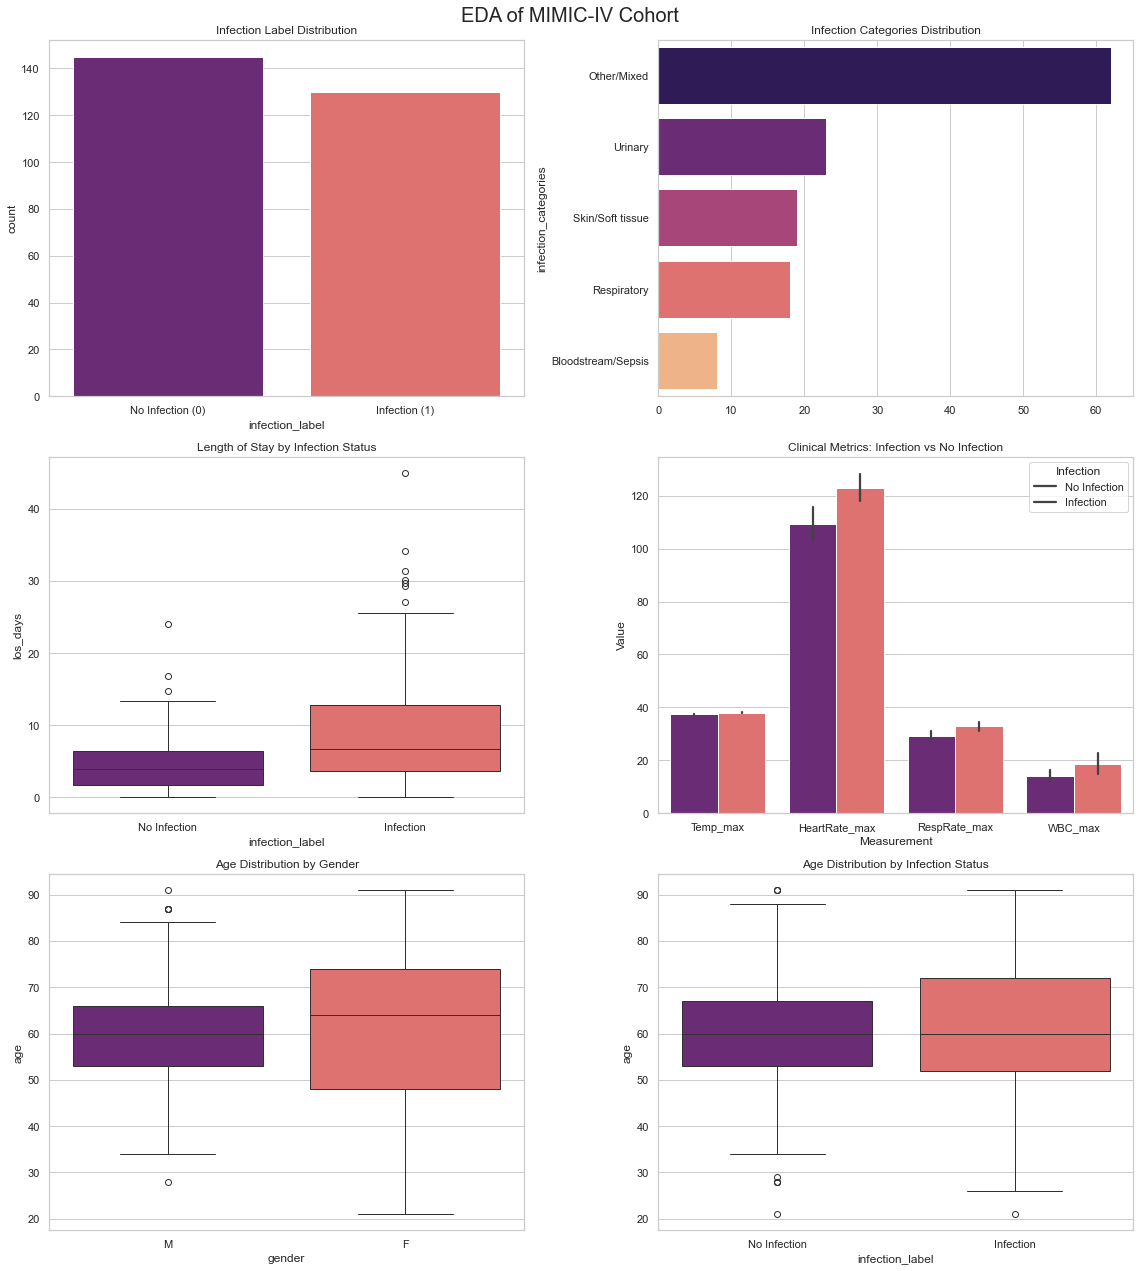

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the dataframe is loaded (assuming df exists from previous step, 
# if not, uncomment the next line)
# df = pd.read_csv('unified_table.csv')

# Set aesthetic theme
sns.set_theme(style="whitegrid")

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
# Title for the entire figure
plt.suptitle("EDA of MIMIC-IV Cohort", fontsize=20)

# 1. Infection Label Distribution
sns.countplot(data=df, x='infection_label', ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Infection Label Distribution')
axes[0, 0].set_xticklabels(['No Infection (0)', 'Infection (1)'])

# 2. Infection Categories Distribution
inf_cats = df[df['infection_categories'] != '']['infection_categories'].value_counts()
sns.barplot(x=inf_cats.values, y=inf_cats.index, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Infection Categories Distribution')

# 3. Length of Stay (LOS) by Infection Status
sns.boxplot(data=df, x='infection_label', y='los_days', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Length of Stay by Infection Status')
axes[1, 0].set_xticklabels(['No Infection', 'Infection'])

# 4. Clinical Metrics Comparison (Grouped Bar Chart)
# Melt the metrics to long format for easy plotting
metrics = ['Temp_max', 'HeartRate_max', 'RespRate_max', 'WBC_max']
df_melted = df.melt(id_vars=['infection_label'], value_vars=metrics, 
                    var_name='Measurement', value_name='Value')
sns.barplot(data=df_melted, x='Measurement', y='Value', hue='infection_label', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Clinical Metrics: Infection vs No Infection')
axes[1, 1].legend(title='Infection', labels=['No Infection', 'Infection'])

# 5. Age Distribution by Gender
sns.boxplot(data=df, x='gender', y='age', ax=axes[2, 0], palette='magma')
axes[2, 0].set_title('Age Distribution by Gender')

# 6. Age Distribution by Infection Status
sns.boxplot(data=df, x='infection_label', y='age', ax=axes[2, 1], palette='magma')
axes[2, 1].set_title('Age Distribution by Infection Status')
axes[2, 1].set_xticklabels(['No Infection', 'Infection'])

# Final adjustments
path_to_save = ROOT / "reports" / "eda_mimic.png"
plt.tight_layout()
plt.savefig(path_to_save)